In [1]:
import pandas as pd
df = pd.read_csv('cleaned_diabetic_data.csv')
df.shape

(69990, 53)

In [2]:
df['A1C_tested'] = df['A1Cresult'].notna()

In [3]:
# target
y = df['readmitted_30']

# a starting feature set based on what EDA showed
features = [
    'age_midpoint', 'time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_diagnoses', 'number_inpatient',
    'number_outpatient', 'number_emergency', 'race', 'gender', 'insulin', 'change', 'diag_1_group', 'A1C_tested'
]
X = df[features]
X.head()

,age_midpoint,time_in_hospital,num_medications,num_lab_procedures,number_diagnoses,number_inpatient,number_outpatient,number_emergency,race,gender,insulin,change,diag_1_group,A1C_tested
0,85.0,13,28,68,8,0,0,0,Caucasian,Female,Steady,Ch,Circulatory,False
1,95.0,12,18,33,8,0,0,0,Caucasian,Female,Steady,Ch,Circulatory,False
2,45.0,1,8,51,5,0,0,0,Caucasian,Male,Steady,Ch,Neoplasms,False
3,45.0,9,17,47,9,0,0,0,AfricanAmerican,Female,Steady,No,Diabetes,False
4,55.0,3,16,31,9,0,0,0,Caucasian,Male,Steady,No,Circulatory,False


In [4]:
X = pd.get_dummies(X, columns=['race','gender','insulin','change','diag_1_group'], drop_first=True)
X.head()

,age_midpoint,time_in_hospital,num_medications,num_lab_procedures,number_diagnoses,number_inpatient,number_outpatient,number_emergency,A1C_tested,race_Asian,...,change_No,diag_1_group_Diabetes,diag_1_group_Digestive,diag_1_group_Genitourinary,diag_1_group_Injury,diag_1_group_Missing,diag_1_group_Musculoskeletal,diag_1_group_Neoplasms,diag_1_group_Other,diag_1_group_Respiratory
0,85.0,13,28,68,8,0,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,95.0,12,18,33,8,0,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,1,8,51,5,0,0,0,False,False,...,False,False,False,False,False,False,False,True,False,False
3,45.0,9,17,47,9,0,0,0,False,False,...,True,True,False,False,False,False,False,False,False,False
4,55.0,3,16,31,9,0,0,0,False,False,...,True,False,False,False,False,False,False,False,False,False


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.20, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(55992, 29) (13998, 29)


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

predictions = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.93      0.63      0.75     12741
           1       0.12      0.52      0.20      1257

    accuracy                           0.62     13998
   macro avg       0.53      0.57      0.47     13998
weighted avg       0.86      0.62      0.70     13998



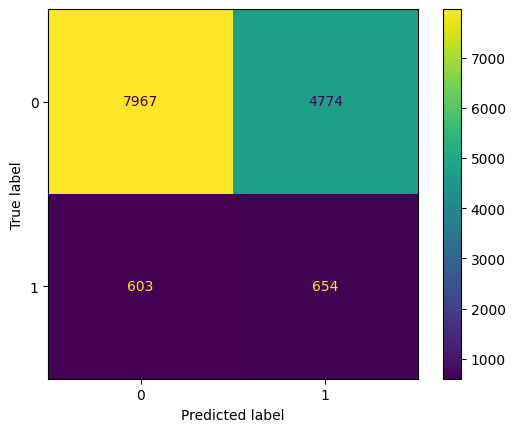

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, class_weight = 'balanced_subsample', random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     12741
           1       0.09      0.00      0.00      1257

    accuracy                           0.91     13998
   macro avg       0.50      0.50      0.48     13998
weighted avg       0.84      0.91      0.87     13998



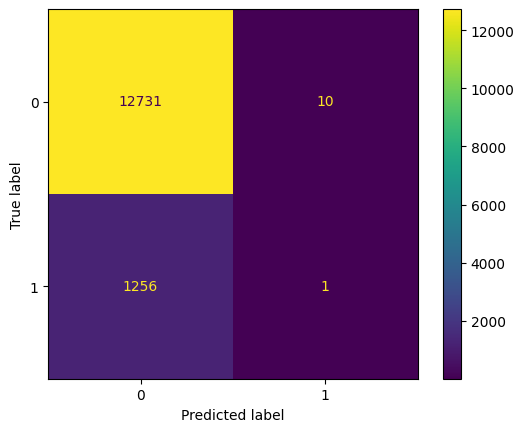

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_predictions)
plt.show()

In [14]:
# lowering the decision threshold
# instead of the default 0.5 cutoff, using predicted probabilities and a lower threshold to catch more positives
probs = rf_model.predict_proba(X_test)[:, 1]
rf_predictions_adjusted = (probs > 0.02).astype(int)
print(classification_report(y_test, rf_predictions_adjusted))

              precision    recall  f1-score   support

           0       0.94      0.10      0.18     12741
           1       0.09      0.94      0.17      1257

    accuracy                           0.17     13998
   macro avg       0.52      0.52      0.17     13998
weighted avg       0.87      0.17      0.17     13998



In [15]:
coefficients = pd.Series(model.coef_[0], index= X_train.columns).sort_values(ascending=False)
print(coefficients.head(10)) # strongest positive predictors
print(coefficients.tail(10)) # strongest negative predictors

number_inpatient        0.360571
number_emergency        0.133648
time_in_hospital        0.050016
diag_1_group_Missing    0.042649
number_diagnoses        0.032890
diag_1_group_Injury     0.025306
age_midpoint            0.009483
race_Caucasian          0.003740
num_lab_procedures      0.001558
num_medications        -0.000921
dtype: float64
diag_1_group_Musculoskeletal   -0.104904
A1C_tested                     -0.117571
race_Unknown                   -0.129670
race_Other                     -0.142086
insulin_Steady                 -0.144205
diag_1_group_Other             -0.146102
diag_1_group_Neoplasms         -0.155643
diag_1_group_Digestive         -0.214491
insulin_No                     -0.229806
diag_1_group_Respiratory       -0.338486
dtype: float64


In [16]:
# saving the model's key outputs for write-up
top_predictors = coefficients.head(5)
bottom_predictors = coefficients.tail(5)

print('Top risk-increasing factors:')
print(top_predictors)
print('\nTop risk-decreasing factors:')
print(bottom_predictors)

Top risk-increasing factors:
number_inpatient        0.360571
number_emergency        0.133648
time_in_hospital        0.050016
diag_1_group_Missing    0.042649
number_diagnoses        0.032890
dtype: float64

Top risk-decreasing factors:
diag_1_group_Other         -0.146102
diag_1_group_Neoplasms     -0.155643
diag_1_group_Digestive     -0.214491
insulin_No                 -0.229806
diag_1_group_Respiratory   -0.338486
dtype: float64
